In [18]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# generating X_synthetic and y_synthetic
X_synthetic, y_synthetic = make_classification(
    n_samples=1000, n_features=200,
    n_informative=3, n_redundant=10,
    n_repeated=0, n_classes=2,
    n_clusters_per_class=2,
    weights=None, flip_y=0.01,
    class_sep=0.8, hypercube=True,
    shift=0.0, scale=1.0,
    shuffle=True, random_state=24
)

In [10]:
# Examining synthetic data
print(X_synthetic.shape, y_synthetic.shape)
print(np.mean(y_synthetic))

(1000, 200) (1000,)
0.501


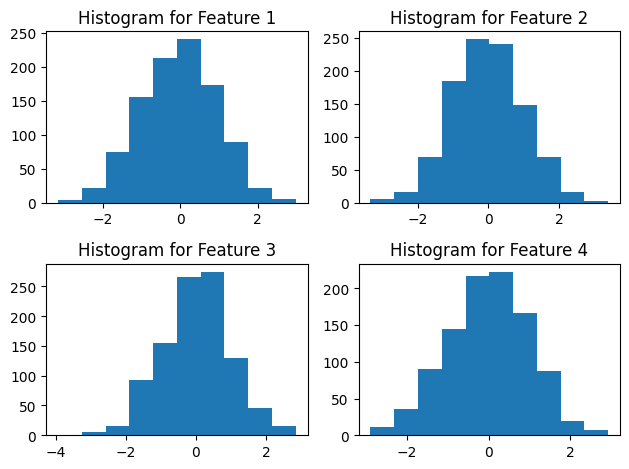

In [11]:
# Plotting the features (sample) to see the distribution
for plot_index in range(4):
  plt.subplot(2, 2, plot_index+1)
  plt.hist(X_synthetic[:, plot_index])
  plt.title('Histogram for Feature {}'.format(plot_index+1))
plt.tight_layout()

The data is balanced

In [12]:
# Splitting the data and intialize logistic regression
X_train, X_test, y_train, y_test = train_test_split(X_synthetic, y_synthetic, test_size=0.2, random_state=24)
lr = LogisticRegression(solver='liblinear', penalty='l1', C=1000, random_state=1)
lr.fit(X_train, y_train)

LogisticRegression(C=1000, penalty='l1', random_state=1, solver='liblinear')

penalty='l1' mean that we use L1 regularization method. Then C=1000 is we using the 'inverse regularization strength', higher C value, is correspond to less regularization, in this case, we are using relatively small regularization.

In [13]:
# Calculating training score, by first getting predicted probability then obtain the ROC AUC
y_train_preprob = lr.predict_proba(X_train)
roc_auc_score(y_train, y_train_preprob[:,1])

np.float64(0.9420000000000001)

In [14]:
# Calculating the test score
from sklearn.metrics import roc_auc_score
y_test_preprob = lr.predict_proba(X_test)
roc_auc_score(y_test, y_test_preprob[:,1])

np.float64(0.8075807580758075)

The training data is higher than the test data, maybe the model is overfit?

**Demonstrating the usage of Regularization to reduce overfit**

In [15]:
# Defining exponent with the power of 10
C_val_exponents = np.linspace(3,-3,13)
C_val_exponents

array([ 3. ,  2.5,  2. ,  1.5,  1. ,  0.5,  0. , -0.5, -1. , -1.5, -2. ,
       -2.5, -3. ])

In [17]:
# Vary C with the power of 10
C_val = float(10)**C_val_exponents
C_val

array([1.00000000e+03, 3.16227766e+02, 1.00000000e+02, 3.16227766e+01,
       1.00000000e+01, 3.16227766e+00, 1.00000000e+00, 3.16227766e-01,
       1.00000000e-01, 3.16227766e-02, 1.00000000e-02, 3.16227766e-03,
       1.00000000e-03])

In [25]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve

# Defining a function that takes k-folds CV splitter, C_vals, model, and features and response
def cross_val_C(k_folds, C_val, model, X, y):
  n_folds = k_folds.n_splits
  cv_train_roc_auc = np.empty((n_folds, len(C_val)))
  cv_test_roc_auc = np.empty((n_folds, len(C_val)))
  cv_test_roc = [ [] ] * len(C_val)

  for c_val_counter in range(len(C_val)):
    # Set the value for the model object
    model.C = C_val[c_val_counter]
    # Count folds for each value of C
    fold_counter = 0
    for train_index, test_index in k_folds.split(X, y):
      X_train, X_test = X[train_index], X[test_index]
      y_train, y_test = y[train_index], y[test_index]

      model.fit(X_train, y_train)

      y_train_predict_proba = model.predict_proba(X_train)
      cv_train_roc_auc[fold_counter, c_val_counter] = roc_auc_score(y_train, y_train_predict_proba[:,1])

      y_test_predict_proba = model.predict_proba(X_test)
      cv_test_roc_auc[fold_counter, c_val_counter] = roc_auc_score(y_test, y_test_predict_proba[:,1])

      this_fold_roc = roc_curve(y_test, y_test_predict_proba[:,1])
      cv_test_roc[c_val_counter].append(this_fold_roc)

      fold_counter += 1

  return cv_train_roc_auc, cv_test_roc_auc, cv_test_roc

In [26]:
# Create a list of empty string
cv_test_roc = [ [] ]*len(C_val)

Using *len(C_val) indicates that should be a list of tuples of metrics (TPR, FPR, threshold) for each value of C.

In [28]:
# Perform cross-validation
k_folds = KFold(n_splits=5, shuffle=True, random_state=24)
cv_train_roc_auc, cv_test_roc_auc, cv_test_roc = cross_val_C(k_folds, C_val, lr, X_synthetic, y_synthetic)

/tmp/ipython-input-2181851791.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color=cm.get_cmap('viridis')(this_fold/k_folds.n_splits),\
/tmp/ipython-input-2181851791.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color=cm.get_cmap('viridis')(this_fold/k_folds.n_splits),\


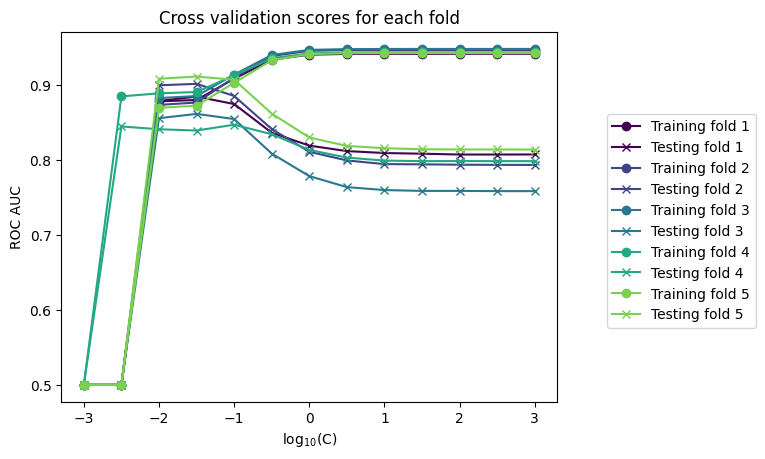

In [30]:
# Plot
import matplotlib.cm as cm

for this_fold in range(k_folds.n_splits):
    plt.plot(C_val_exponents, cv_train_roc_auc[this_fold], '-o',\
             color=cm.get_cmap('viridis')(this_fold/k_folds.n_splits),\
             label='Training fold {}'.format(this_fold+1))
    plt.plot(C_val_exponents, cv_test_roc_auc[this_fold], '-x',\
             color=cm.get_cmap('viridis')(this_fold/k_folds.n_splits),\
             label='Testing fold {}'.format(this_fold+1))
plt.ylabel('ROC AUC')
plt.xlabel('log$_{10}$(C)')
plt.legend(loc = [1.1, 0.2])
plt.title('Cross validation scores for each fold')
plt.show()

Text(0.5, 1.0, 'Cross validation scores averaged over all folds')

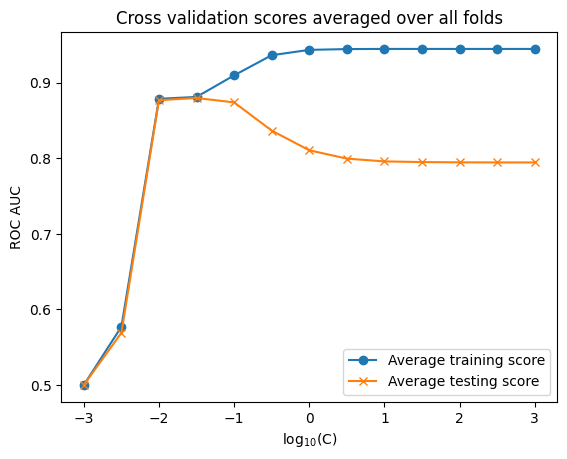

In [31]:
plt.plot(C_val_exponents, np.mean(cv_train_roc_auc, axis=0), \
         '-o', label='Average training score')
plt.plot(C_val_exponents, np.mean(cv_test_roc_auc, axis=0), \
         '-x', label='Average testing score')
plt.ylabel('ROC AUC')
plt.xlabel('log$_{10}$(C)')
plt.legend()
plt.title('Cross validation scores averaged over all folds')

In [33]:
# Create boolean mask to find C = 10-1.5
best_C_val_bool = C_val_exponents == -1.5
best_C_val_bool.astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [37]:
# Convert the array into single integer
best_C_val_ix = np.nonzero(best_C_val_bool.astype(int))
best_C_val_ix[0][0]

np.int64(9)

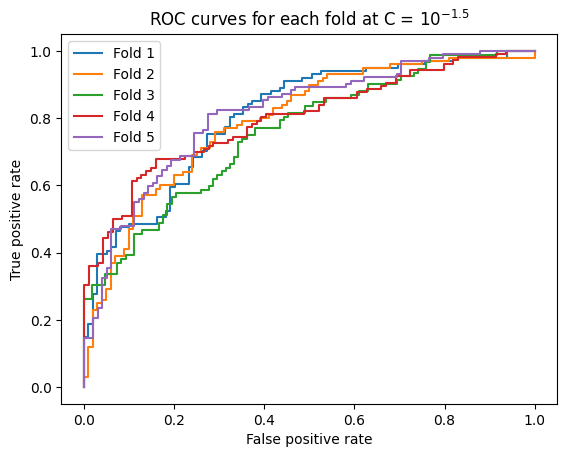

In [39]:
# Plot
for this_fold in range(k_folds.n_splits):
    fpr = cv_test_roc[best_C_val_ix[0][0]][this_fold][0]
    tpr = cv_test_roc[best_C_val_ix[0][0]][this_fold][1]
    plt.plot(fpr, tpr, label='Fold {}'.format(this_fold+1))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves for each fold at C = $10^{-1.5}$')
plt.legend()

There is fair amount of variability on the ROC Curves.

In [40]:
# Train the model
lr.C = 10**(-1.5)
lr.fit(X_train, y_train)

LogisticRegression(C=0.03162277660168379, penalty='l1', random_state=1,
                   solver='liblinear')

In [41]:
# Predicttt train data and get the roc score
y_train_predict_proba = lr.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba[:,1])

np.float64(0.8802812499999999)

In [42]:
# Calculate the test data roc score
y_test_predict_proba = lr.predict_proba(X_test)
roc_auc_score(y_test, y_test_predict_proba[:,1])

np.float64(0.8847884788478848)

After applying regularization, we can see that the score of train and test data is close to similar. So, the model is balanced.

In [44]:
# Search !=0 in the coefficients of trained model
sum((lr.coef_ != 0)[0])

np.int64(2)

In [45]:
# Examine the value of those !=0
lr.intercept_

array([0.])

Now, the intercept has been regularized to 0